In [1]:
import torch
import clip
import os
from torchvision import transforms, datasets

from utils import clip_analysis_utils
from utils import similarity

In [2]:
clip_name = "ALIGN"      #"ViT-B/16" or "ALIGN"
# concept_set = "data/concept_sets/cub_filtered.txt"
dataset = "cub"
d_train = dataset + "_train"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

dataset_path = os.path.join(os.getcwd(), "Data\CUB_200_2011")
used_ground_truth_concepts = False  #wether we compare it to the original CUB attributes or not
concept_file = "single_roc_concept.txt"
comparison_to_ground_truth = 'class_ground_truth' #which field to use for comparison if using ground truth concepts. class_ground_truth = probability per class straight from file. ground_truth_mean = mean over images in class from is_present attribute.
use_certainty = False  #whether to use certainty information from attributes file or just standard is_present

In [3]:
#definitions:
def my_similarity(a, b):
    return a @ b.T  #dot product

In [4]:
attributes_cub = clip_analysis_utils.parse_attributes_file(dataset_path, "attributes\\image_attribute_labels.txt", use_certainty)

In [5]:
#cleaned_concepts, cleaned_not_concepts, grouped_concepts = clip_analysis_utils.get_cleaned_concepts(dataset_path, "attributes.txt") #original CUB attributes
#cleaned_concepts, cleaned_not_concepts, grouped_concepts = clip_analysis_utils.get_cleaned_concepts(os.path.join(os.getcwd(), "Data\Concept_sets"), "cub_filtered.txt", used_ground_truth_concepts)  #filtered concepts
#cleaned_concepts, cleaned_not_concepts, grouped_concepts = clip_analysis_utils.get_cleaned_concepts(os.path.join(os.getcwd(), ""), "run_final_concepts.txt", used_ground_truth_concepts)  #filtered concepts
cleaned_concepts, cleaned_not_concepts, grouped_concepts = clip_analysis_utils.get_cleaned_concepts(os.path.join(os.getcwd(), "test"), concept_file, used_ground_truth_concepts)  #filtered concepts

In [7]:
mult_scores, not_mult_scores = clip_analysis_utils.get_clip_similarity_all(clip_name, cleaned_concepts, my_similarity, cleaned_not_concepts, device)

100%|██████████| 1/1 [00:00<00:00, 75.07it/s]


In [9]:
# If only one concept is used, get its index in the original CUB attributes and compare to that
ground_truth_concept_idx = -1
if len(cleaned_concepts) == 1:
    original_concepts = clip_analysis_utils.get_cleaned_concepts(dataset_path, "attributes.txt")[0]  #original CUB attributes
    #get concept index for true concept
    for i, concept in enumerate(original_concepts):
        if concept == cleaned_concepts[0]:
            ground_truth_concept_idx = i + 1  #attribute ids start from 1
            print("Found ground truth concept'", cleaned_concepts[0],"' at idx: ", ground_truth_concept_idx)
            break



ground_truth = [attributes_cub[j+1][ground_truth_concept_idx][0] for j in range(len(mult_scores))]      #(len(images)), list of ground truth for each image (starting at idx 0)

Found ground truth concept' has leg color rufous ' at idx:  268


11788 torch.Size([11788, 1]) torch.Size([11788]) [0, 1]
Max score: 0.21557064354419708 Min score: 0.07184718549251556


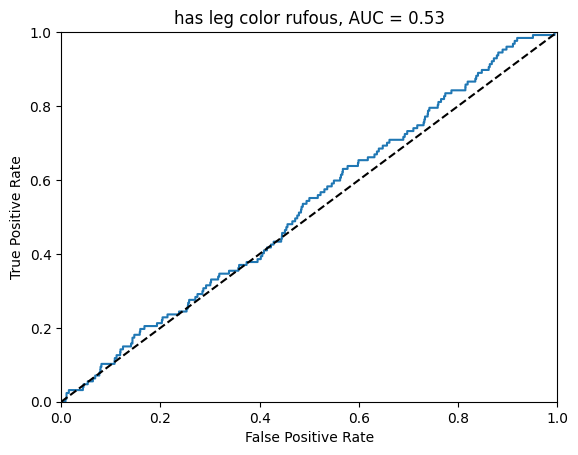

AUC: 0.5258094989219736


In [10]:
print(len(attributes_cub), mult_scores.shape, mult_scores.squeeze().shape, attributes_cub[1][ground_truth_concept_idx])
max_score = mult_scores.max().item()
min_score = mult_scores.min().item()
print("Max score:", max_score, "Min score:", min_score)

auc_result = clip_analysis_utils.plot_roc_curve(ground_truth, mult_scores[:, 0], concept_name=cleaned_concepts[0])
print("AUC:", auc_result)
